In [2]:
from google.colab import drive
drive.mount('/content/drive')

RUN_DIR = "/content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640"
WEIGHTS_DIR = f"{RUN_DIR}/weights"
BEST_PT = f"{WEIGHTS_DIR}/best.pt"
LAST_PT = f"{WEIGHTS_DIR}/last.pt"

print("RUN_DIR:", RUN_DIR)
print("BEST:", BEST_PT)
print("LAST:", LAST_PT)

Mounted at /content/drive
RUN_DIR: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640
BEST: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640/weights/best.pt
LAST: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640/weights/last.pt


1) Checks básicos de que todo existe

In [3]:
import os

assert os.path.exists(BEST_PT), "No existe best.pt"
assert os.path.exists(RUN_DIR), "No existe la carpeta del run"

print("Archivos en weights:", os.listdir(WEIGHTS_DIR))
for f in ["results.csv", "args.yaml"]:
    p = f"{RUN_DIR}/{f}"
    print(f, "->", "OK" if os.path.exists(p) else "NO")

Archivos en weights: ['best.pt', 'last.pt']
results.csv -> OK
args.yaml -> OK


2) Instalar Ultralytics + cargar modelo

In [4]:
!pip -q install ultralytics

from ultralytics import YOLO
model = YOLO(BEST_PT)
print("Modelo cargado:", BEST_PT)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Modelo cargado: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640/weights/best.pt


3) Recuperar el data.yaml usado en el entrenamiento

In [5]:
import yaml, os

args_path = f"{RUN_DIR}/args.yaml"
with open(args_path, "r") as f:
    args = yaml.safe_load(f)

data_path = args.get("data", None)
print("data usado en train:", data_path)

# Si la ruta no existe (porque era /content...), la sustituimos por la del dataset en Drive si está allí.
# Si se sigue usando el zip->/content, entonces para val/test tendrás que volver a descomprimir o apuntar a un yaml en Drive.

data usado en train: /content/weapons_det/dataset_full/data.yaml


4A) Unzip dataset otra vez (solo para evaluación)

In [6]:
import os, shutil, zipfile, glob

ZIP_PATH = "/content/drive/MyDrive/TFM/datasets/weapons_cs231n/raw_zip/weapons_yolov8.zip"
WORK_DIR = "/content/weapons_det_eval"
DATA_DIR = f"{WORK_DIR}/dataset_full"

os.makedirs(WORK_DIR, exist_ok=True)
local_zip = f"{WORK_DIR}/dataset.zip"
shutil.copy(ZIP_PATH, local_zip)

if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR, exist_ok=True)

with zipfile.ZipFile(local_zip, "r") as z:
    z.extractall(DATA_DIR)

candidates = glob.glob(f"{DATA_DIR}/**/data.yaml", recursive=True)
yaml_path = candidates[0]
ROOT = os.path.dirname(yaml_path)

print("yaml_path:", yaml_path)
print("ROOT:", ROOT)

yaml_path: /content/weapons_det_eval/dataset_full/data.yaml
ROOT: /content/weapons_det_eval/dataset_full


5) Evaluación en val (y test si existe)

In [7]:
import os

# Val
val_metrics = model.val(data=yaml_path)
print("VAL listo.")

# Test (si existe split test en el yaml)
# Ultralytics usa el split definido; si el yaml incluye test: se puede pasar split='test' en versiones recientes.
try:
    test_metrics = model.val(data=yaml_path, split="test")
    print("TEST listo.")
except Exception as e:
    print("No pude correr split=test (puede que el yaml no tenga test o versión ultralytics no lo soporte). Error:", e)

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1317.0±329.5 MB/s, size: 39.6 KB)
val: Scanning /content/weapons_det_eval/dataset_full/valid/labels... 2544 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2544/2544 1.8Kit/s 1.4s
val: New cache created: /content/weapons_det_eval/dataset_full/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 159/159 4.0it/s 39.9s
                   all       2544       2883       0.96      0.946      0.975      0.761
Speed: 1.4ms preprocess, 8.7ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val
VAL listo.
Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1288.4±445.2 MB/s, size: 46.9 KB

6) Mostrar las imágenes de resultados del run

In [8]:
import os
from PIL import Image
import matplotlib.pyplot as plt

def show_img(path, title=None):
    if not os.path.exists(path):
        print("No existe:", path); return
    img = Image.open(path)
    plt.figure(figsize=(10,6))
    plt.imshow(img)
    plt.axis("off")
    if title: plt.title(title)
    plt.show()

for fn in ["results.png", "PR_curve.png", "confusion_matrix.png", "F1_curve.png", "P_curve.png", "R_curve.png"]:
    show_img(f"{RUN_DIR}/{fn}", title=fn)

No existe: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640/results.png
No existe: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640/PR_curve.png
No existe: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640/confusion_matrix.png
No existe: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640/F1_curve.png
No existe: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640/P_curve.png
No existe: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640/R_curve.png


7) Predicciones en un subset de validación/test y guardar en Drive

In [9]:
import glob, random, os, shutil

# detecta split val/valid
val_split = "valid" if os.path.isdir(os.path.join(ROOT, "valid")) else "val"
val_img_dir = os.path.join(ROOT, val_split, "images")

imgs = glob.glob(val_img_dir + "/*")
samples = random.sample(imgs, k=min(50, len(imgs)))

OUT_DIR = "/content/weapon_preds"
if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)

model.predict(
    source=samples,
    imgsz=640,
    conf=0.15,
    save=True,
    project=OUT_DIR,
    name="pred"
)

print("Predicciones en:", OUT_DIR + "/pred")


0: 640x640 1 gun, 9.7ms
1: 640x640 1 gun, 9.7ms
2: 640x640 1 gun, 9.7ms
3: 640x640 1 gun, 9.7ms
4: 640x640 1 gun, 9.7ms
5: 640x640 (no detections), 9.7ms
6: 640x640 1 gun, 9.7ms
7: 640x640 2 guns, 9.7ms
8: 640x640 1 gun, 9.7ms
9: 640x640 1 gun, 9.7ms
10: 640x640 1 gun, 9.7ms
11: 640x640 2 guns, 9.7ms
12: 640x640 1 gun, 9.7ms
13: 640x640 1 gun, 9.7ms
14: 640x640 4 guns, 9.7ms
15: 640x640 2 guns, 9.7ms
16: 640x640 1 gun, 9.7ms
17: 640x640 1 gun, 9.7ms
18: 640x640 1 gun, 9.7ms
19: 640x640 1 gun, 9.7ms
20: 640x640 1 gun, 9.7ms
21: 640x640 1 gun, 9.7ms
22: 640x640 (no detections), 9.7ms
23: 640x640 1 gun, 9.7ms
24: 640x640 1 gun, 9.7ms
25: 640x640 1 gun, 9.7ms
26: 640x640 1 gun, 9.7ms
27: 640x640 2 guns, 9.7ms
28: 640x640 1 gun, 9.7ms
29: 640x640 1 gun, 9.7ms
30: 640x640 1 gun, 9.7ms
31: 640x640 1 gun, 9.7ms
32: 640x640 1 gun, 9.7ms
33: 640x640 2 guns, 9.7ms
34: 640x640 1 gun, 9.7ms
35: 640x640 1 gun, 9.7ms
36: 640x640 1 gun, 9.7ms
37: 640x640 13 guns, 9.7ms
38: 640x640 1 gun, 9.7ms
39: 64

8) Copiar outputs a Drive (persistente)

In [10]:
import shutil, os

PRED_SRC = "/content/weapon_preds/pred"
PRED_DST = f"{RUN_DIR}/pred_samples_val_50"

if os.path.exists(PRED_DST):
    shutil.rmtree(PRED_DST)
shutil.copytree(PRED_SRC, PRED_DST)

print("Copiado a Drive:", PRED_DST)

Copiado a Drive: /content/drive/MyDrive/TFM/experiments/weapon_det/yolov8s_weapons_A_e80_640/pred_samples_val_50


9) Leer results.csv y sacar el “mejor epoch” y métricas finales

In [11]:
import pandas as pd

csv_path = f"{RUN_DIR}/results.csv"
df = pd.read_csv(csv_path)
display(df.tail(10))

# Mejor epoch según mAP50-95 en val
best_idx = df["metrics/mAP50-95(B)"].idxmax()
best_row = df.loc[best_idx]

print("\nMejor epoch (por mAP50-95):", int(best_row["epoch"]))
print(best_row[["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]])

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
39,40,14599.2,0.88647,0.61186,1.17161,0.95400,0.93518,0.96654,0.73979,0.94191,0.48171,1.09390,0.015521,0.005174,0.015521,0.005174,0.015521,0.005174,0.015521,0.005174
40,41,14954.8,0.87730,0.60476,1.16455,0.95704,0.93548,0.96923,0.74177,0.93759,0.47659,1.09382,0.015150,0.005050,0.015150,0.005050,0.015150,0.005050,0.015150,0.005050
41,42,15310.6,0.87273,0.60061,1.16131,0.95625,0.94173,0.96957,0.74474,0.94089,0.47538,1.09560,0.014779,0.004926,0.014779,0.004926,0.014779,0.004926,0.014779,0.004926
42,43,15665.4,0.86756,0.59042,1.15264,0.95317,0.94416,0.97208,0.74970,0.93174,0.47028,1.08315,0.014408,0.004803,0.014408,0.004803,0.014408,0.004803,0.014408,0.004803
43,44,16018.0,0.85611,0.58833,1.15378,0.96122,0.94583,0.97337,0.75083,0.92616,0.46669,1.08430,0.014036,0.004679,0.014036,0.004679,0.014036,0.004679,0.014036,0.004679
44,45,16377.4,0.85367,0.58827,1.14991,0.95929,0.94802,0.97400,0.75415,0.91741,0.46192,1.07826,0.013665,0.004555,0.013665,0.004555,0.013665,0.004555,0.013665,0.004555
45,46,16733.9,0.84413,0.56937,1.13993,0.96340,0.94034,0.97418,0.75683,0.91496,0.45604,1.07617,0.013294,0.004431,0.013294,0.004431,0.013294,0.004431,0.013294,0.004431
46,47,17095.4,0.84197,0.56927,1.14268,0.96279,0.94238,0.97380,0.75955,0.90862,0.45431,1.07270,0.012922,0.004307,0.012922,0.004307,0.012922,0.004307,0.012922,0.004307
47,48,17454.4,0.83147,0.56748,1.13651,0.96275,0.94138,0.97433,0.75992,0.90177,0.44643,1.06540,0.012551,0.004184,0.012551,0.004184,0.012551,0.004184,0.012551,0.004184
48,49,17816.3,0.82543,0.56107,1.12891,0.96021,0.94596,0.97495,0.76074,0.89856,0.44295,1.06040,0.012180,0.004060,0.012180,0.004060,0.012180,0.004060,0.012180,0.004060



Mejor epoch (por mAP50-95): 49
metrics/precision(B)    0.96021
metrics/recall(B)       0.94596
metrics/mAP50(B)        0.97495
metrics/mAP50-95(B)     0.76074
Name: 48, dtype: float64


10. Visualizar predicciones

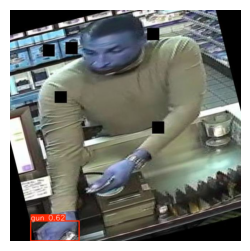

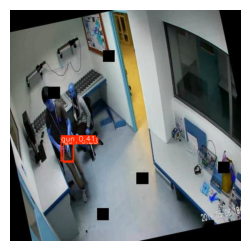

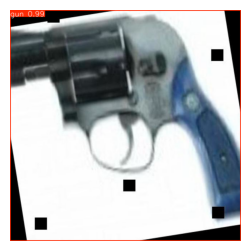

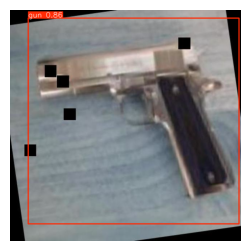

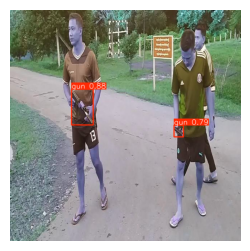

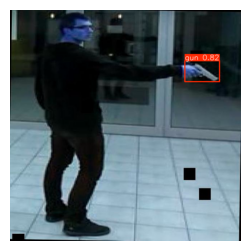

In [18]:
import glob, random, os
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

# Detectar split
val_split = "valid" if os.path.isdir(os.path.join(ROOT, "valid")) else "val"
val_img_dir = os.path.join(ROOT, val_split, "images")

imgs = glob.glob(val_img_dir + "/*")
samples = random.sample(imgs, k=min(6, len(imgs)))

results = model.predict(source=samples, imgsz=640, conf=0.15)

for r in results:
    im_array = r.plot()  # imagen con bbox dibujadas
    plt.figure(figsize=(3,3))
    plt.imshow(im_array)
    plt.axis("off")
    plt.show()

### Mostrar casos con mayor y menor confianza

#### Mayor confianza

In [13]:
high_conf_imgs = []

for img_path in random.sample(imgs, k=100):
    r = model.predict(source=img_path, imgsz=640, conf=0.01, verbose=False)[0]
    if r.boxes is not None and len(r.boxes) > 0:
        max_conf = float(r.boxes.conf.max())
        high_conf_imgs.append((img_path, max_conf))

high_conf_imgs = sorted(high_conf_imgs, key=lambda x: -x[1])[:5]
print("Top 5 más confiadas:")
high_conf_imgs

Top 5 más confiadas:


[('/content/weapons_det_eval/dataset_full/valid/images/armas_314_jpg.rf.ec2491c75844b181772c91ff08bc2b2a.jpg',
  0.9913768768310547),
 ('/content/weapons_det_eval/dataset_full/valid/images/armas_2663_jpg.rf.b14cbe174852f9245c9cca0e3fc61770.jpg',
  0.9903866052627563),
 ('/content/weapons_det_eval/dataset_full/valid/images/armas_2394_jpg.rf.4cec6aa5bb0d870d52ea05179806a615.jpg',
  0.9871047735214233),
 ('/content/weapons_det_eval/dataset_full/valid/images/armas_2955_jpg.rf.a7536a5c573b2ff59942bc4710faef8c.jpg',
  0.9836633205413818),
 ('/content/weapons_det_eval/dataset_full/valid/images/armas_1131_jpg.rf.e9b9c0b126162a6f8dca672b7289b616.jpg',
  0.982930064201355)]

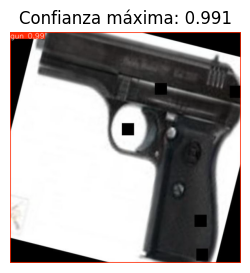

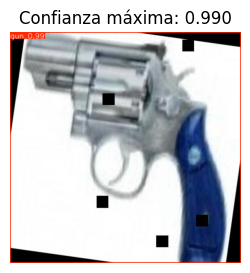

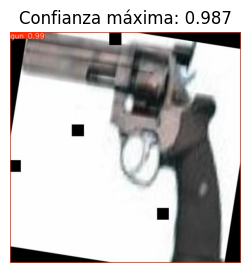

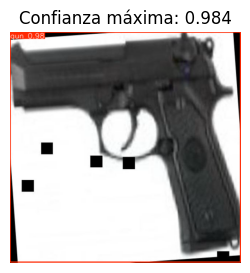

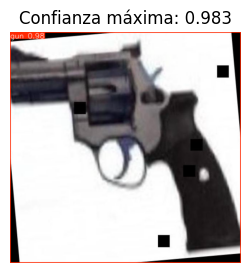

In [17]:
for img_path, conf in high_conf_imgs:
    # Predicción
    result = model.predict(source=img_path, imgsz=640, conf=0.01, verbose=False)[0]
    # Imagen con bounding boxes dibujadas
    im_array = result.plot()
    plt.figure(figsize=(3,3))
    plt.imshow(im_array)
    plt.title(f"Confianza máxima: {conf:.3f}")
    plt.axis("off")
    plt.show()

#### Menor confianza

In [21]:
results = model.predict(source=val_img_dir, imgsz=640, conf=0.01, verbose=False)

conf_list = []

for r in results:
    if r.boxes is not None and len(r.boxes) > 0:
        max_conf = float(r.boxes.conf.max())
        conf_list.append((r.path, max_conf))

low_conf_imgs = sorted(conf_list, key=lambda x: x[1])[:5]
low_conf_imgs

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs



[('/content/weapons_det_eval/dataset_full/valid/images/real-video-408-_jpg.rf.2ef81ebcaafcee3b4273aca8686f370c.jpg',
  0.011183313094079494),
 ('/content/weapons_det_eval/dataset_full/valid/images/Arrest039_00041_jpg.rf.903d38987cc79ab6870691c36f6c295f.jpg',
  0.02496703714132309),
 ('/content/weapons_det_eval/dataset_full/valid/images/pistol_868_jpg.rf.71e458d2fb6d3ca6cd9d71849ca9bd9e.jpg',
  0.026079267263412476),
 ('/content/weapons_det_eval/dataset_full/valid/images/CAR00199_jpg.rf.15cb03c96e94959e2ed337acea0820c9.jpg',
  0.030286578461527824),
 ('/content/weapons_det_eval/dataset_full/valid/images/Gun_2745_jpg.rf.9d5df2ba4a0df6d22a6d448e0a07f40f.jpg',
  0.03176452964544296)]

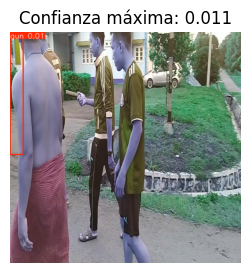

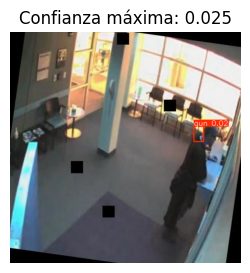

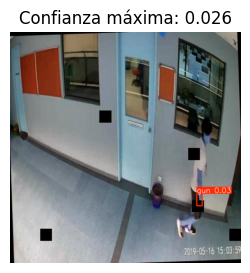

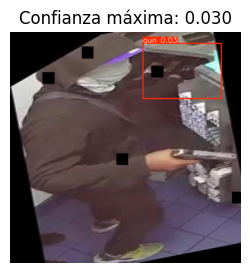

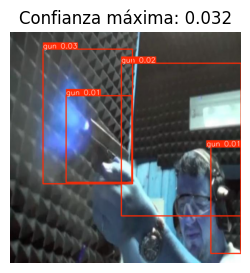

In [22]:
for img_path, conf in low_conf_imgs:
    # Predicción
    result = model.predict(source=img_path, imgsz=640, conf=0.01, verbose=False)[0]
    # Imagen con bounding boxes dibujadas
    im_array = result.plot()
    plt.figure(figsize=(3,3))
    plt.imshow(im_array)
    plt.title(f"Confianza máxima: {conf:.3f}")
    plt.axis("off")
    plt.show()

### Falsos Positivos - Falsos Negativos

Detectar split test y rutas

In [25]:
import os, glob

# Asumo que ya tienes ROOT (carpeta donde vive train/val/test)
# Si no: ROOT = os.path.dirname(yaml_path)

def pick_split(root):
    if os.path.isdir(os.path.join(root, "test")):
        return "test"
    raise FileNotFoundError("No encuentro carpeta test en ROOT")

split = pick_split(ROOT)
img_dir = os.path.join(ROOT, split, "images")
lbl_dir = os.path.join(ROOT, split, "labels")

imgs = glob.glob(img_dir + "/*")
labels = glob.glob(lbl_dir + "/*.txt")

print("Split:", split)
print("N imágenes:", len(imgs))
print("N labels:", len(labels))

Split: test
N imágenes: 623
N labels: 623


Funciones: leer labels YOLO, IoU, y visual GT vs pred

In [28]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_EXTS = (".jpg",".jpeg",".png",".bmp",".webp")

def read_yolo_labels(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, "r") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            parts = ln.split()
            cls = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:5])
            boxes.append((cls, x, y, w, h))
    return boxes

def xywhn_to_xyxyn(x, y, w, h):
    return np.array([x - w/2, y - h/2, x + w/2, y + h/2], dtype=float)

def iou_xyxyn(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0.0, inter_x2 - inter_x1)
    ih = max(0.0, inter_y2 - inter_y1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter + 1e-12
    return inter / union

def show_gt_pred(img_path, lbl_dir, conf_th=0.25, imgsz=640):
    # GT
    stem = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(lbl_dir, stem + ".txt")
    gt = read_yolo_labels(label_path)

    # Pred
    r = model.predict(source=img_path, imgsz=imgsz, conf=conf_th, verbose=False)[0]

    # Load image
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]
    out = img_rgb.copy()

    # GT in green
    for (cls, x, y, w, h) in gt:
        x1 = int((x - w/2) * W); y1 = int((y - h/2) * H)
        x2 = int((x + w/2) * W); y2 = int((y + h/2) * H)
        cv2.rectangle(out, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(out, "GT", (x1, max(15,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    # Pred in red
    if r.boxes is not None and len(r.boxes) > 0:
        for box in r.boxes:
            x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
            c = float(box.conf)
            cv2.rectangle(out, (x1,y1), (x2,y2), (255,0,0), 2)
            cv2.putText(out, f"P {c:.2f}", (x1, min(H-5, y1+20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
    else:
        cv2.putText(out, "NO DETECTIONS", (15,30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,0,0), 2)

    plt.figure(figsize=(7,7))
    plt.imshow(out); plt.axis("off")
    plt.show()

Escanear el test y sacar candidatos FP/FN

In [29]:
conf_th = 0.25
iou_th = 0.50

split = "test"
img_dir = os.path.join(ROOT, split, "images")
lbl_dir = os.path.join(ROOT, split, "labels")

imgs = glob.glob(img_dir + "/*")

false_positives = []  # (img_path, max_conf)
false_negatives = []  # img_path

neg_count = 0
pos_count = 0

for img_path in imgs:  # en tu caso son 623, se puede hacer completo
    stem = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(lbl_dir, stem + ".txt")
    gt = read_yolo_labels(label_path)

    r = model.predict(source=img_path, imgsz=640, conf=conf_th, verbose=False)[0]

    # Predicciones normalizadas (0..1) directamente del modelo
    preds = []
    if r.boxes is not None and len(r.boxes) > 0:
        # r.boxes.xywhn: (N,4) con x,y,w,h normalizados
        for i in range(len(r.boxes)):
            x, y, w, h = r.boxes.xywhn[i].cpu().numpy().tolist()
            c = float(r.boxes.conf[i])
            preds.append((xywhn_to_xyxyn(x,y,w,h), c))

    if len(gt) == 0:
        neg_count += 1
        if len(preds) > 0:
            false_positives.append((img_path, max(c for _, c in preds)))
    else:
        pos_count += 1
        gt_xyxyn = [xywhn_to_xyxyn(x,y,w,h) for (_,x,y,w,h) in gt]

        matched = False
        for p_xyxyn, _ in preds:
            if max(iou_xyxyn(p_xyxyn, g) for g in gt_xyxyn) >= iou_th:
                matched = True
                break

        if not matched:
            false_negatives.append(img_path)

print("Positivos (GT>0):", pos_count)
print("Negativos (GT=0):", neg_count)
print("FP:", len(false_positives))
print("FN:", len(false_negatives))

Positivos (GT>0): 607
Negativos (GT=0): 16
FP: 2
FN: 500


Visualizar 5 falsos positivos y 5 falsos negativos

In [30]:
# Ordena FP por confianza (los más “peligrosos”)
false_positives = sorted(false_positives, key=lambda x: -x[1])

print("=== FP (top 5 por confianza) ===")
for img_path, c in false_positives[:5]:
    print("FP conf:", round(c,3), img_path)
    show_gt_pred(img_path, lbl_dir, conf_th=conf_th)

print("=== FN (5 ejemplos) ===")
for img_path in false_negatives[:5]:
    print("FN:", img_path)
    # Para FN, baja conf para ver si hay predicciones débiles
    show_gt_pred(img_path, lbl_dir, conf_th=0.05)

Output hidden; open in https://colab.research.google.com to view.